In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
train_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v3.csv"

train_df = pd.read_csv(train_path)

print(train_df.shape)

train_df.head()

(242965, 88)


,acc_resultant_mean,acc_resultant_std,acc_resultant_variance,acc_resultant_min,acc_resultant_max,acc_resultant_median,acc_resultant_rms,acc_resultant_skewness,acc_resultant_kurtosis,acc_resultant_q25,...,yaw_rms,yaw_skewness,yaw_kurtosis,yaw_q25,yaw_q75,yaw_iqr,driver,trip,road_type,behavior
0,0.062950,0.037494,0.001406,0.012961,0.178804,0.058821,0.073110,0.994585,0.711390,0.033116,...,0.026448,0.142478,-1.728146,-0.03325,-0.01400,0.01925,D6,20151221120051-26km-D6-AGGRESSIVE-MOTORWAY,MOTORWAY,AGGRESSIVE
1,0.060696,0.034344,0.001179,0.012961,0.144686,0.056502,0.069598,0.821860,0.113281,0.033116,...,0.026217,0.081806,-1.758558,-0.03325,-0.01400,0.01925,D6,20151221120051-26km-D6-AGGRESSIVE-MOTORWAY,MOTORWAY,AGGRESSIVE
2,0.060563,0.034495,0.001190,0.012961,0.144686,0.056502,0.069556,0.807773,0.093973,0.033116,...,0.025936,0.018867,-1.769954,-0.03325,-0.01375,0.01950,D6,20151221120051-26km-D6-AGGRESSIVE-MOTORWAY,MOTORWAY,AGGRESSIVE
3,0.059966,0.034357,0.001180,0.012961,0.144686,0.053694,0.068969,0.863860,0.203253,0.033116,...,0.025623,-0.041783,-1.764851,-0.03325,-0.01300,0.02025,D6,20151221120051-26km-D6-AGGRESSIVE-MOTORWAY,MOTORWAY,AGGRESSIVE
4,0.059171,0.033793,0.001142,0.012961,0.144686,0.053694,0.068001,0.933059,0.452223,0.033116,...,0.025261,-0.102163,-1.749063,-0.03225,-0.01300,0.01925,D6,20151221120051-26km-D6-AGGRESSIVE-MOTORWAY,MOTORWAY,AGGRESSIVE


In [7]:
print(train_df.info())

print(train_df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242965 entries, 0 to 242964
Data columns (total 88 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   acc_resultant_mean       242965 non-null  float64
 1   acc_resultant_std        242965 non-null  float64
 2   acc_resultant_variance   242965 non-null  float64
 3   acc_resultant_min        242965 non-null  float64
 4   acc_resultant_max        242965 non-null  float64
 5   acc_resultant_median     242965 non-null  float64
 6   acc_resultant_rms        242965 non-null  float64
 7   acc_resultant_skewness   242965 non-null  float64
 8   acc_resultant_kurtosis   242965 non-null  float64
 9   acc_resultant_q25        242965 non-null  float64
 10  acc_resultant_q75        242965 non-null  float64
 11  acc_resultant_iqr        242965 non-null  float64
 12  acc_horizontal_mean      242965 non-null  float64
 13  acc_horizontal_std       242965 non-null  float64
 14  acc_

In [8]:
target_column = "behavior"

feature_columns = [

    col

    for col in train_df.columns

    if col not in [

        "behavior",
        "driver",
        "trip",
        "road_type"

    ]

]

X = train_df[feature_columns]

y = train_df[target_column]

groups = train_df["trip"]

print(X.shape)

print(groups.nunique())

(242965, 84)
32


In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [10]:
from sklearn.model_selection import GroupKFold

group_kfold = GroupKFold(
    n_splits=6
)

In [11]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [12]:
fold_results = []

confusion_matrices = []

fold = 1

for train_idx, val_idx in group_kfold.split(X, y, groups):

    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y[train_idx]
    y_val = y[val_idx]

    rf_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(
        X_train,
        y_train
    )

    y_pred = rf_model.predict(X_val)

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    print(f"Accuracy : {accuracy:.4f}")

    print(
        classification_report(
            y_val,
            y_pred,
            target_names=label_encoder.classes_
        )
    )

    cm = confusion_matrix(
        y_val,
        y_pred
    )

    confusion_matrices.append(cm)

    fold_results.append({
        "Fold": fold,
        "Accuracy": accuracy
    })

    fold += 1

Fold 1
Accuracy : 0.4701
              precision    recall  f1-score   support

  AGGRESSIVE       0.70      0.64      0.67     12473
      DROWSY       0.49      0.11      0.18     17709
      NORMAL       0.37      0.80      0.51     12921

    accuracy                           0.47     43103
   macro avg       0.52      0.52      0.45     43103
weighted avg       0.52      0.47      0.42     43103

Fold 2
Accuracy : 0.3718
              precision    recall  f1-score   support

  AGGRESSIVE       0.42      0.32      0.37     11982
      DROWSY       0.63      0.05      0.09     15563
      NORMAL       0.35      0.73      0.47     15551

    accuracy                           0.37     43096
   macro avg       0.47      0.37      0.31     43096
weighted avg       0.47      0.37      0.30     43096

Fold 3
Accuracy : 0.4865
              precision    recall  f1-score   support

  AGGRESSIVE       0.67      0.61      0.64     15853
      DROWSY       0.00      0.00      0.00         0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy : 0.4556
              precision    recall  f1-score   support

  AGGRESSIVE       0.00      0.00      0.00         0
      DROWSY       0.40      0.28      0.33     13949
      NORMAL       0.59      0.55      0.57     25313

    accuracy                           0.46     39262
   macro avg       0.33      0.28      0.30     39262
weighted avg       0.52      0.46      0.48     39262

Fold 5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy : 0.3866
              precision    recall  f1-score   support

  AGGRESSIVE       0.87      0.29      0.44     15553
      DROWSY       0.05      0.03      0.04      9330
      NORMAL       0.37      0.72      0.49     14097

    accuracy                           0.39     38980
   macro avg       0.43      0.35      0.32     38980
weighted avg       0.49      0.39      0.36     38980

Fold 6
Accuracy : 0.6332
              precision    recall  f1-score   support

  AGGRESSIVE       0.52      0.84      0.65      7900
      DROWSY       0.41      0.45      0.43      6450
      NORMAL       0.79      0.61      0.69     24911

    accuracy                           0.63     39261
   macro avg       0.57      0.64      0.59     39261
weighted avg       0.67      0.63      0.64     39261



In [13]:
results_df = pd.DataFrame(fold_results)

print(results_df)

print()

print(
    f"Mean Accuracy : {results_df['Accuracy'].mean():.4f}"
)

print(
    f"Std Accuracy : {results_df['Accuracy'].std():.4f}"
)

   Fold  Accuracy
0     1  0.470060
1     2  0.371821
2     3  0.486489
3     4  0.455631
4     5  0.386583
5     6  0.633173

Mean Accuracy : 0.4673
Std Accuracy : 0.0934


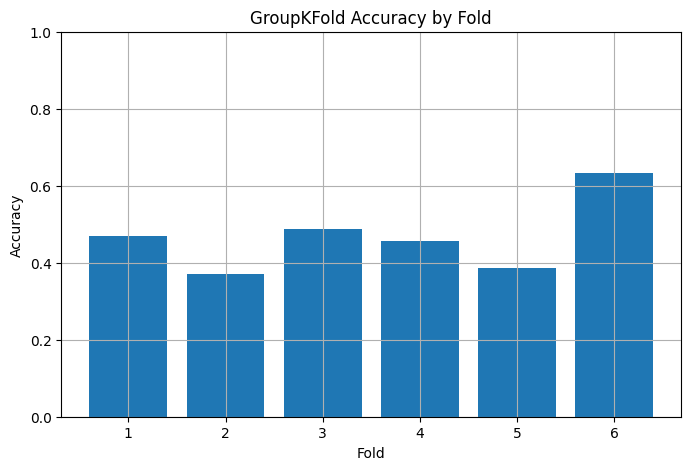

In [14]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Fold"],
    results_df["Accuracy"]
)

plt.ylim(0,1)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("GroupKFold Accuracy by Fold")

plt.grid(True)

plt.show()

In [16]:
results_df.to_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/results/groupkfold_randomforest_results.csv",
    index=False
)